# **Project work: Retinal Layer Segmentation in SD-OCT with Graph Theory**

<div style="color:#777777;margin-top: -15px;">
<b>Course</b>: MSLS / CO4 |
<b>Version</b>: v1.3 <br><br>
<!-- 10.04.2025, v1.2: Fully refactored -->
<!-- 17.04.2026, v1.3: Introduced word count limits -->
</div>


**Student**: $\Rightarrow$ Alex Zimmermann  
**Email**: $\Rightarrow$ alex.zimmermann@students.fhnw.ch    
**University**: $\Rightarrow$  FHNW  
**Semester**: $\Rightarrow$  SS 2026  
**Date**: $\Rightarrow$  29.05.2026


---

## **Abstract**

This project segments retinal layer boundaries in cross-sectional
Spectral-Domain Optical Coherence Tomography (SD-OCT) B-scans of the
human eye. We compare expert manual annotations against an automated
segmentation with graph theory that models each B-scan as a directed
graph and finds layer boundaries with Dijkstra's shortest-path
algorithm [Dijkstra, 1959]. We extend the approach from a single layer
(Inner Limiting Membrane, ILM) to three layers (ILM, IS/OS
junction, RPE/Bruch's membrane) via sequential constrained Dijkstra.
On the 11 expert-annotated slices of one subject we obtain a mean
absolute surface distance of **≈ 1.5 px ≈ 5.8 µm**, on the order of
the inter-annotator disagreement between the two human graders bundled
with the dataset [Chiu et al., 2015]. We also compare against two
naive baselines (Otsu thresholding, per-column gradient argmax) that
fail with errors ~40–100× larger, and verify generalisation by
re-running the same pipeline on a second subject.

---

## **Table of contents**
* [1. Dataset](#sec_dataset)
* [2. Preprocessing](#sec_preprocessing)
* [3. Manual segmentation](#sec_manual_segmentation)
* [4. Automated segmentation](#sec_automated_segmentation)
* [5. Evaluation](#sec_evaluation)
* [6. Discussion](#sec_discussion)
* [References & GenAI ](#sec_references)


---

## **Prerequisites / Setup**

This notebook requires `numpy`, `scipy`, `scikit-image`, `opencv-python`,
`matplotlib` and `pandas`, along with the `src/` package which contains
the preprocessing, segmentation, baseline and evaluation modules. The
course `tools/` helper module is also imported for the plotting tools.


In [115]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2 as cv
import scipy.io

# Jupyter / IPython configuration:
# Automatically reload modules when modified
%load_ext autoreload
%autoreload 2

# Enable vectorized output (for nicer plots)
%config InlineBackend.figure_formats = ["svg"]

# Inline backend configuration
%matplotlib inline

# course plotting tools
import tools
tools.setup_plotting()

# project modules
sys.path.insert(0, ".")
from src import (
    preprocess_oct, preprocess_steps,
    compute_cost_image, compute_cost_image_bright_to_dark,
    dijkstra_layer, column_ilm_prior,
    segment_ilm, segment_layer_below, segment_three_layers,
    boundary_to_mask, nan_boundary_to_mask,
    baseline_otsu, baseline_gradient_argmax,
    dice_score, mean_absolute_surface_distance, max_surface_distance, evaluate,
)

# paths from current folder
ROOT = Path(".")
SLICE_DIR = ROOT / "data" / "slices"
PRE_DIR   = ROOT / "data" / "preprocessed"
GT_DIR    = ROOT / "data" / "ground_truth"
AUTO_DIR  = ROOT / "masks" / "auto"
MAN_DIR   = ROOT / "masks" / "manual"
FIG_DIR   = ROOT / "figures"
# make fig directory if not made
FIG_DIR.mkdir(exist_ok=True)

# conversion: Heidelberg Spectralis HRA+OCT axial resolution in tissue (Chiu et al., 2015): 3.87 µm per pixel.
PX_TO_UM = 3.87

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

<a id='sec_dataset'></a>

## **1. Dataset**

### **Motivation**

**Spectral-Domain Optical Coherence Tomography (SD-OCT)** is a non-invasive
imaging technique that produces cross-sectional images
(B-scans) of biological tissue by measuring back-scattered low-coherence
light interferometrically [Huang et al., 1991]. In ophthalmology it is the
standard tool to visualise the layered structure of the retina, and is
used to diagnose age-related macular degeneration, diabetic
retinopathy and glaucoma. Each B-scan is a 2-D slice (depth × width) of a
3-D volume, in which the retinal layers appear as alternating bright
(highly back-scattering) and dark (weakly back-scattering) bands.

### **Source**

For this project we use: **Duke SD-OCT dataset for Diabetic Macular Edema (DME)** released
with the publication [Chiu et al., 2015]:

> Chiu, S. J., Allingham, M. J., Mettu, P. S., Cousins, S. W., Izatt, J. A.,
> & Farsiu, S. (2015). *Kernel regression based segmentation of optical
> coherence tomography images with diabetic macular edema.* Biomedical
> Optics Express **6**(4), 1172–1194. doi:[10.1364/BOE.6.001172](https://doi.org/10.1364/BOE.6.001172).
>
> Dataset: <http://www.duke.edu/~sf59/Datasets/2015_BOE_Chiu2.zip>

The full dataset consists of **10 subjects × 61 B-scans (496 × 768 px,
8-bit grayscale)** centred on the fovea, acquired on a Heidelberg
Spectralis HRA+OCT (axial resolution of 3.87 µm/px in tissue, lateral
resolution of 11.36 µm/px). Each subject's volume is contained in a
MATLAB `.mat` file with two manual annotations of
eight retinal layer boundaries (one per ~5–10 slices per subject) and
the fluid masks.

### **Subset used here**

Here we use **two subjects**:
* `Subject_02.mat` — primary subject for all experiments,
  with 11 expert annotated slices.
* `Subject_06.mat` — secondary subject used to test
  generalisation.

These eleven slices per subject are exported to individual PNG files at
`data/slices/` and `data/slices_sub06/`.

### **Structures of interest**

Here the focus is on three retinal boundaries:

| index | dataset layer | name | physical signature |
|-------|---------------|------|---------------------|
| 1 | 0 | Inner Limiting Membrane (ILM) | dark vitreous → bright NFL |
| 2 | 5 | IS/OS junction | bright dark→bright transition deep in retina |
| 3 | 7 | RPE / Bruch's membrane | bright RPE → dark choroid |

The ILM is the most identifiable boundary with high
contrast and provides a good starting point. The 
IS/OS junction is one of the brightest features in
the retina. RPE/Bruch's membrane is the deepest boundary and
has opposite transition (bright to dark), which demonstrates that
the graph framework can generalise to other boundary types with a simple
sign change in the cost function.

### **License**

The Duke dataset is provided for *research and educational use only*
[Chiu et al., 2015]. The publication must be cited. Re-distribution
and commercial use are not permitted. Images are de-identified.


In [116]:
# load Subject_02 and show contents
mat = scipy.io.loadmat("data/raw/2015_BOE_Chiu/Subject_02.mat")
print("Subject_02.mat contents:")
for k, v in mat.items():
    if not k.startswith("__"):
        print(f"  {k:24s} shape={v.shape}  dtype={v.dtype}")

Subject_02.mat contents:
  images                   shape=(496, 768, 61)  dtype=uint8
  automaticFluidDME        shape=(496, 768, 61)  dtype=float64
  manualFluid1             shape=(496, 768, 61)  dtype=float64
  manualFluid2             shape=(496, 768, 61)  dtype=float64
  automaticLayersDME       shape=(8, 768, 61)  dtype=float64
  automaticLayersNormal    shape=(8, 768, 61)  dtype=float64
  manualLayers1            shape=(8, 768, 61)  dtype=float64
  manualLayers2            shape=(8, 768, 61)  dtype=float64


In [117]:
# load the per-slice "ground-truth" ILM
# pre extracted with 'src/extract_slices.py'
gt = np.load(GT_DIR / "ilm_boundaries.npz")
expert1 = gt["expert1"]           
expert2 = gt["expert2"]

slice_indices = gt["slice_indices"]
N_SLICES, W = expert1.shape

# print # slices, width and indices
print(f"{N_SLICES} annotated slices, image width = {W} px")
print(f"Subject_02 slice indices: {slice_indices.tolist()}")

11 annotated slices, image width = 768 px
Subject_02 slice indices: [10, 15, 20, 25, 28, 30, 32, 35, 40, 45, 50]


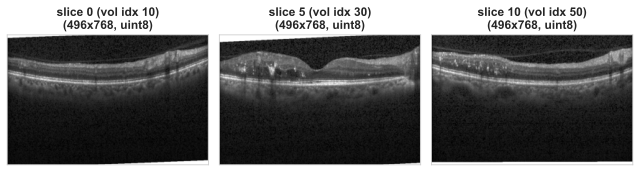

In [118]:
# Three B-scans (peripheral, fovea, peripheral)
slices_to_show = [0, 5, 10]
imgs = [cv.imread(str(SLICE_DIR / f"slice_{i:02d}.png"), cv.IMREAD_GRAYSCALE)
        for i in slices_to_show]
tools.show_image_chain(
    imgs,
    titles=[f"slice {i} (vol idx {slice_indices[i]})" for i in slices_to_show],
)

---

<a id='sec_preprocessing'></a>

## **2. Preprocessing**

### **Dealing with noise (speckle)**

SD-OCT images contain speckle noise, a granular noise pattern from coherent light interference
inside the tissue. Speckle statistics follow a Rayleigh / Gamma
distribution [Schmitt et al., 1999] and is not additive
Gaussian, so naive low-pass filtering blurs the layer boundaries we
want to keep. We therefore need a pipeline to preserve the edges.

### **Pipeline**

Apply three filters in order:

1. **Median filter (3×3)** to try and remove isolated speckle pixels.
2. **Bilateral filter** [Tomasi & Manduchi, 1998] allows averages locally
   and penalising intensity differences, so it smooths the speckle
   without removing layer boundaries.
3. **CLAHE** (Contrast-Limited Adaptive Histogram Equalisation, 8×8
   tiles) [Zuiderveld, 1994] which boosts local contrast so the dark
   vitreous and bright NFL are clearly separated.

All three are implemented in `src/preprocessing.py` and shown as
`preprocess_oct(img)`; the helper `preprocess_steps(img)` returns each
intermediate stage for visualisation. All three filters run in $O(H \cdot W)$ per slice.


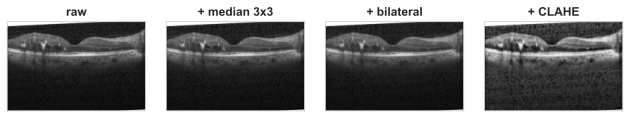

In [119]:
# apply and show preprocessing step by stpe
img = cv.imread(str(SLICE_DIR / "slice_05.png"), cv.IMREAD_GRAYSCALE)
steps = preprocess_steps(img)
tools.show_image_chain(
    [steps["raw"], steps["median"], steps["bilateral"], steps["clahe"]],
    titles=["raw", "+ median 3x3", "+ bilateral", "+ CLAHE"],
    # fig_size = () not working fix later
    suppress_info=True,
)

### **Effect of each filter**

Here we can attempt to view th effect of each filter. First, through a visual zoom on a dark patch of the image to view noise reduction.

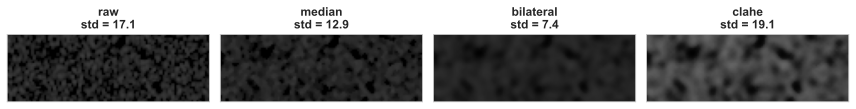

In [120]:
# visualize speckle reduction (visual + std)
img = cv.imread(str(SLICE_DIR / "slice_05.png"), cv.IMREAD_GRAYSCALE)
steps = preprocess_steps(img)
patch = (slice(20, 60), slice(300, 420))     # select vitreous w/ no layer

# plot selection with std
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, name in zip(axes, ("raw", "median", "bilateral", "clahe")):
    p = steps[name][patch]
    ax.imshow(p, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{name}\nstd = {p.std():.1f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / "preprocessing_patch.png", dpi=150, bbox_inches="tight")
plt.show()

Visual differences can be observed with the median filter successfully filtering isolated speckle providing more grouped patches followed by the bilateral filter further reducing speckle through smoothing. This is mirrored by the standard deviation of pixel intensities within the patch. The final step boosts contrast in turn elevating the std but enables later edge contrast with the kept smoothing and noise reduction from previous steps.

In [121]:
# save the full preprocessed images
for k in range(N_SLICES):
    img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
    cv.imwrite(str(PRE_DIR / f"slice_{k:02d}.png"), preprocess_oct(img_k))
print( N_SLICES, "preprocessed slices to:", PRE_DIR)

11 preprocessed slices to: data\preprocessed


---

<a id='sec_manual_segmentation'></a>

## **3. Manual segmentation**

### **Fiji Workflow**

For manual annotation we segment the ILM in **Fiji**
[Schindelin et al., 2012] on one B-scan through the following:

1. `File → Open` the preprocessed PNG (`data/preprocessed/slice_05.png`).
2. Select the **Freehand Line** tool and trace the ILM (the topmost
   sharp dark→bright transition) from left to right.
3. `Edit → Selection → Line to Area`, then `Edit → Selection → Create Mask`.
4. `File → Save As → PNG` to export the mask.

A single B-scan can take of large amounts of time of careful tracing. Additionally, Freehand tracing is incredibly hard without proper tools such as a tablet and stylus. 

Further attempts were made with segmented line through fiji and tailored tools such as Segment Editor in ITK-SNAP. Different methods could be potentially evaluated in python for example with Napari or AI assisted methods such as pixel classification in QUPath.




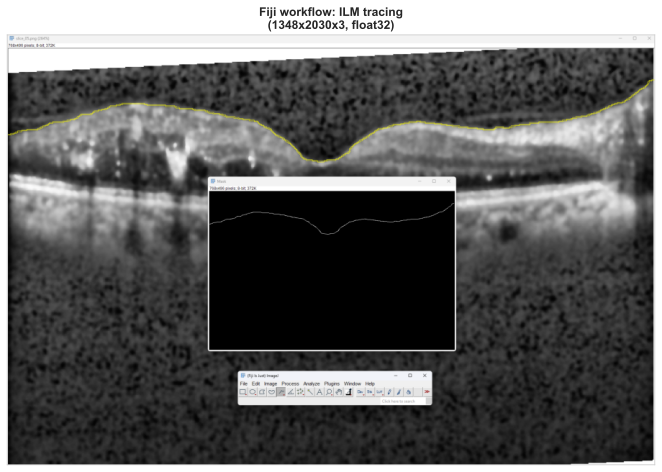

In [122]:
# manual attempt example

tools.show_image(str(GT_DIR / "manual_final_slice5.png"), title="Fiji workflow: ILM tracing")

# Sorry for the terrible freehand! I tried my not very good best...




### **Use of expert annotations**

As the dataset comes with expertly annotated slices, we use these
(`manualLayers1`, `manualLayers2`, 11 slices × 768 columns each) as
ground truth for evaluation. Each annotation is a
per-column row index of the layer; we turn it into a ±2-pixel band
mask so that the Dice score can be meaningfully computed against the
(also ±2-pixel) automatic mask. 

These manual segmentations were performed by two ophthalmologists manually using custom software further described in [Chiu et al., 2015].

In [123]:
# convert the expert annotations to ±2 px band masks
for k in range(N_SLICES):
    img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
    mask_man = nan_boundary_to_mask(expert1[k], img_k.shape, band=2)
    cv.imwrite(str(MAN_DIR / f"slice_{k:02d}.png"), mask_man)
print(f"Wrote {N_SLICES} manual masks to {MAN_DIR}/")

Wrote 11 manual masks to masks\manual/


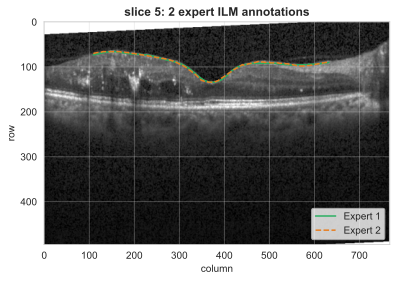

In [124]:
# show B-scan slice 5 with expert annotations
k = 5
img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
fig, ax = plt.subplots(figsize=(9, 4))
ax.imshow(img_k, cmap="gray")
xs = np.arange(W)
ax.plot(xs, expert1[k], color="#27ae60", lw=1.5, label="Expert 1")
ax.plot(xs, expert2[k], color="#e67e22", lw=1.5, ls="--", label="Expert 2")
ax.set(title=f"slice {k}: 2 expert ILM annotations", xlabel="column", ylabel="row")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "manual_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

---

<a id='sec_automated_segmentation'></a>

## **4. Automated segmentation — Graph theory + Dijkstra**

### **4.1 Graph theory**

We can consider a retinal layer boundary to be a 1-D curve across the full
width of the image, one row per column with a limit set to how far we can move
vertically from column to column. A graph "shortes-path" formulations suits 
the structural constraints compared to say pixel thresholding. 

* We can consider each pixel to be a graph node

* Edges connect nodes from left to right (column 'c' to column 'c+1')

* The current pixel '(r, c)' can then only be connected to `(r-1, c+1)`,
 `(r, c+1)`, `(r+1, c+1)` with a bounded slope of 1 px per column

 * The weights of our edge encodes the information of desire to pass through
 this 1 px boundary. 


The minimum-cost path from any node in column 0 to any node in column
`W-1` is then the optimal boundary.


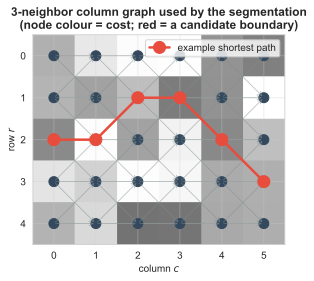

In [125]:
# 3-neighbor column-graph structure
fig, ax = plt.subplots(figsize=(8, 4))
H_demo, W_demo = 5, 6
rng = np.random.default_rng(0)
costs = rng.random((H_demo, W_demo))
ax.imshow(costs, cmap="Greys", aspect="equal", alpha=0.55,
          extent=(-0.5, W_demo - 0.5, H_demo - 0.5, -0.5))
# nodes
for r in range(H_demo):
    for c in range(W_demo):
        ax.plot(c, r, "o", color="#34495e", ms=10, zorder=3)
# 3-neighbor edges from each pixel except the last column
for r in range(H_demo):
    for c in range(W_demo - 1):
        for dr in (-1, 0, 1):
            nr = r + dr
            if 0 <= nr < H_demo:
                ax.annotate("", xy=(c + 1, nr), xytext=(c, r),
                            arrowprops=dict(arrowstyle="->",
                                            color="#7f8c8d", lw=0.8,
                                            alpha=0.55))
# a hypothetical shortest path
path_rows = [2, 2, 1, 1, 2, 3]
ax.plot(range(W_demo), path_rows, "-o", color="#e74c3c",
        ms=12, lw=2.5, zorder=4, label="example shortest path")
ax.set_xlim(-0.5, W_demo - 0.5); ax.set_ylim(H_demo - 0.5, -0.5)
ax.set_xlabel("column $c$"); ax.set_ylabel("row $r$")
ax.set_title("3-neighbor column graph used by the segmentation\n"
             "(node colour = cost; red = a candidate boundary)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "graph_schematic.png", dpi=150, bbox_inches="tight")
plt.show()

### **4.2 Cost function**

The ILM is a dark-above to bright-below transition, which gives a
strong vertical gradient $\partial I/\partial r$. We compute this with a Sobel operator 
[Sobel & Feldman, 1968], clip negative values to avoid bright to dark
and  normalise to $[0, 1]$ and invert:

$$
C(r, c) \;=\; 1 \;-\;
   \frac{\max\bigl(0, \partial_r I(r,c)\bigr)}
        {\max_{r',c'}\;\max(0, \partial_r I(r',c'))}.
$$

So $C \approx 0$ on a strong ILM-like edge and $C \approx 1$ elsewhere.
The cost of a candidate boundary $r(c)$ is then $\sum_c C(r(c), c)$. For
boundaries with an opposite transition (e.g. RPE/choroid: bright above, dark
below) we use the mirror cost
`compute_cost_image_bright_to_dark(img)` with the only changing
being the sign of the gradient before clipping.

### **4.3 Why a prior is necessary**

Several deeper retinal boundaries (NFL/GCL, IPL/INL, IS/OS, …) are
*also* dark→bright transitions. Naïve Dijkstra often locks onto the
brightest one rather than the topmost one. Two further
complications in this dataset:

* The Duke B-scans have a constant white band at the
  top of each image (likely due to cropping). The algorithm therefore
  will follow this edge between this band and the first real
  image row.
* In fovea slices the retina is very thin and several edges lie close
  together.

This is solved with a per-column prior, heavily smoothed "first
strong dark→bright transition" estimate per column, with outlier
rejection (>6 MAD from the median) and horizontal smoothing
(`column_ilm_prior(img)` in `src/segmentation.py`). Dijkstra is 
constrained to a ±25-pixel band around this to guarantee it trackes 
the ILM.

### **4.4 Dijkstra**

The recurrence is

$$
\text{dist}[r, c] \;=\; \min_{r' \in \{r-1, r, r+1\}}
   \bigl(\text{dist}[r', c-1]\bigr) + C(r, c),
$$

with $\text{dist}[r, 0] = C(r, 0)$ and a back-pointer for path
reconstruction. We implement it with a binary heap (`heapq`) giving
$O(H W \log(H W))$ complexity.


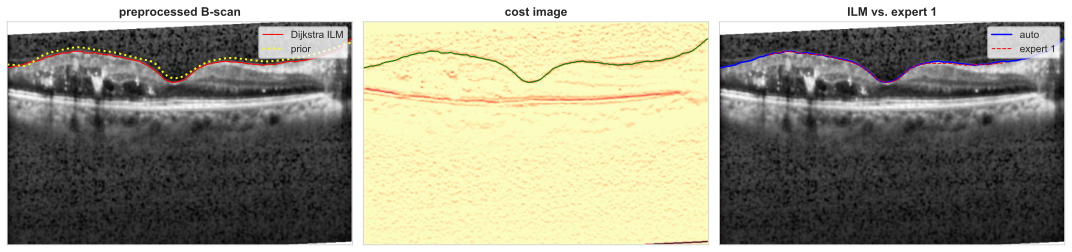

In [126]:
# visualise cost image and ILM recovered
k = 5
img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
pre   = preprocess_oct(img_k)
prior = column_ilm_prior(pre)
boundary, cost = segment_ilm(pre)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(pre, cmap="gray"); axes[0].set_title("preprocessed B-scan")
axes[0].plot(np.arange(W), boundary, color="Red", lw=1, label="Dijkstra ILM")
axes[0].plot(np.arange(W), prior, color="Yellow", lw=2, ls=":", label="prior")
axes[0].legend(loc="upper right")

axes[1].imshow(cost, cmap="magma"); axes[1].set_title("cost image")
axes[1].plot(np.arange(W), boundary, color="Green", lw=1.0)

axes[2].imshow(pre, cmap="gray"); axes[2].set_title("ILM vs. expert 1")
axes[2].plot(np.arange(W), boundary, color="Blue", lw=1.5, label="auto")
axes[2].plot(np.arange(W), expert1[k], color="Red", lw=1, ls="--", label="expert 1")
axes[2].legend(loc="upper right")

for a in axes:
    a.set_xticks([]); a.set_yticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / f"dijkstra_slice_{k:02d}.png", dpi=150, bbox_inches="tight")
plt.show()

In [127]:
# process slices + timer
t0 = time.perf_counter()
results = []

for k in range(N_SLICES):
    img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
    pre   = preprocess_oct(img_k)
    bnd, _ = segment_ilm(pre)
    cv.imwrite(str(AUTO_DIR / f"slice_{k:02d}.png"),
               boundary_to_mask(bnd, img_k.shape, band=2))

    results.append({"k": k, "boundary": bnd, "shape": img_k.shape})

dt = time.perf_counter() - t0

print(f"Segmented {N_SLICES} slices in {dt:.2f} s ")

Segmented 11 slices in 1.39 s 


### **4.5 Extending to other layers**

The same graph framework segments multiple layers when we run Dijkstra
sequentially with exclusion bands. For each slice we attempt to segment 
3 layers. With the initial prior as boundary followed by an allowed search range:

| order | layer | dataset index | polarity | search range from previous boundary |
|-------|--------------------------|---------------|------------------|---------------------------|
| 1     | ILM                       | 0 | dark → bright   | prior |
| 2     | IS/OS          | 5 | dark → bright   | [+40 px, +130 px] below ILM |
| 3     | RPE / Bruch's membrane    | 7 | **bright → dark** | [+4 px, +40 px] below IS/OS |


The later boundary must lie strictly below the previous
one following the anatomical ordering of the
retinal layers without an explicit graph-cut multi-surface formulation
[Chiu et al., 2015]. The RPE/Bruch's boundary uses the mirrored cost
function `compute_cost_image_bright_to_dark(img)`.

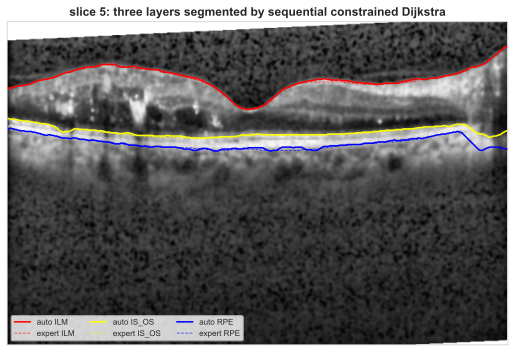

In [128]:
# multilayer segmentation on one slice with 3 boundaries

k = 5

img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)

pre = preprocess_oct(img_k)

layers = segment_three_layers(pre)

# Ground truth for Subject_02
ml1_all = scipy.io.loadmat("data/raw/2015_BOE_Chiu/Subject_02.mat")["manualLayers1"]
s_idx = int(slice_indices[k])
gt_ilm = ml1_all[0, :, s_idx]
gt_isos = ml1_all[5, :, s_idx]
gt_rpe = ml1_all[7, :, s_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(pre, cmap="gray")
xs = np.arange(W)
COLOR = {"ILM": "Red", "IS_OS": "Yellow", "RPE": "Blue"}

for name, gt_b in (("ILM", gt_ilm), ("IS_OS", gt_isos), ("RPE", gt_rpe)):
    ax.plot(xs, layers[name], color=COLOR[name], lw=1.5, label=f"auto {name}")
    ax.plot(xs, gt_b, color=COLOR[name], lw=0.8, ls="--", label=f"expert {name}", alpha=0.7)
ax.set_title(f"slice {k}: three layers segmented by sequential constrained Dijkstra")
ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / f"multilayer_slice_{k:02d}.png", dpi=150, bbox_inches="tight")
plt.show()

---

<a id='sec_evaluation'></a>

## **5. Evaluation**

### **5.1 Mean Absolute Surface Distance (MASD)**

Because a boundary is a 1-D curve, the error measure is the
average column-wise row distance, (converted with
Spectralis axial resolution of 3.87 µm/px [Chiu et al., 2015]):

$$
\text{MASD}(b_\text{pred}, b_\text{gt}) \;=\;
\frac{1}{|\mathcal{C}|}\sum_{c \in \mathcal{C}}
   \bigl|\, b_\text{pred}(c) - b_\text{gt}(c) \
$$

where $\mathcal{C}$ is the set of columns the experts labelled
(the rest is `NaN`). MASD is in pixels.

### **5.2 Dice Similarity Coefficient (DSC)**

For boundary segmentation we dilate each
1-pixel boundary into a ±2-pixel band mask and compute

$$
\text{Dice}(A, B) \;=\; \frac{2 |A \cap B|}{|A| + |B|}.
$$



In [129]:
# slice metrics (Subject_02 ILM)

rows = []

for r in results:
    k = r["k"]; bnd = r["boundary"]; shp = r["shape"]
    masd_e1 = mean_absolute_surface_distance(bnd, expert1[k])
    masd_e2 = mean_absolute_surface_distance(bnd, expert2[k])
    inter   = mean_absolute_surface_distance(expert1[k], expert2[k])
    maxd    = max_surface_distance(bnd, expert1[k])
    m_auto  = boundary_to_mask(bnd, shp, band=2)
    m_man   = nan_boundary_to_mask(expert1[k], shp, band=2)
    d       = dice_score(m_auto, m_man)

    rows.append({
        "slice": k,
        "MASD vs Exp1 [px]": masd_e1,
        "MASD vs Exp1 [µm]": masd_e1 * PX_TO_UM,
        "MASD vs Exp2 [px]": masd_e2,
        "max SD vs Exp1 [px]": maxd,
        "Dice (Exp1, band=2)": d,
        "Exp1 vs Exp2 MASD [px]": inter,
    })

df = pd.DataFrame(rows).set_index("slice")

display(df.round(2))

print()
print(df.describe().round(2))

,MASD vs Exp1 [px],MASD vs Exp1 [µm],MASD vs Exp2 [px],max SD vs Exp1 [px],"Dice (Exp1, band=2)",Exp1 vs Exp2 MASD [px]
slice,,,,,,
0,1.89,7.33,1.08,5.0,0.50,1.92
1,1.28,4.94,1.26,4.0,0.60,0.92
2,0.90,3.50,0.79,4.0,0.66,1.05
3,1.44,5.56,0.90,3.0,0.58,1.49
4,1.43,5.54,1.40,4.0,0.58,1.47
5,1.33,5.14,1.42,5.0,0.60,1.45
6,1.09,4.23,1.43,5.0,0.63,1.13
7,0.98,3.77,0.87,4.0,0.65,0.98
8,2.13,8.25,0.88,5.0,0.47,2.32



       MASD vs Exp1 [px]  MASD vs Exp1 [µm]  MASD vs Exp2 [px]  \
count              11.00              11.00              11.00   
mean                1.47               5.70               1.15   
std                 0.43               1.68               0.25   
min                 0.90               3.50               0.79   
25%                 1.19               4.59               0.89   
50%                 1.43               5.54               1.26   
75%                 1.72               6.67               1.37   
max                 2.18               8.43               1.43   

       max SD vs Exp1 [px]  Dice (Exp1, band=2)  Exp1 vs Exp2 MASD [px]  
count                11.00                11.00                   11.00  
mean                  4.55                 0.57                    1.38  
std                   0.82                 0.07                    0.42  
min                   3.00                 0.46                    0.92  
25%                   4.00        

### **5.3 Baseline**

As the dataset provides two annotations per slice we can compare these to obtain a baseline. The MASD between expert 1 and expert 2 can then be used to compare agaisnt the algortihm's MASD to help determine perdormance.


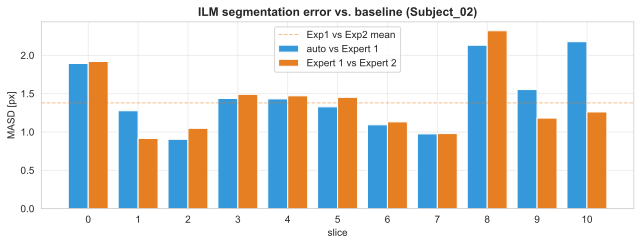

Automatic  vs Expert 1   : 1.47 +/- 0.43 px  (5.7 +/- 1.7 µm)
Expert 1   vs Expert 2   : 1.38 +/- 0.42 px  (5.3 +/- 1.6 µm)


In [130]:
# barchart per-slice MASD vs baseline

fig, ax = plt.subplots(figsize=(9, 3.5))
x = df.index.values
ax.bar(x - 0.2, df["MASD vs Exp1 [px]"], width=0.4,
       label="auto vs Expert 1", color="#3498db")
ax.bar(x + 0.2, df["Exp1 vs Exp2 MASD [px]"], width=0.4,
       label="Expert 1 vs Expert 2", color="#e67e22")
ax.axhline(df["Exp1 vs Exp2 MASD [px]"].mean(), color="#e67e22",
           ls="--", lw=1, alpha=0.5, label="Exp1 vs Exp2 mean")
ax.set(xlabel="slice", ylabel="MASD [px]",
       title="ILM segmentation error vs. baseline (Subject_02)")
ax.legend()
ax.set_xticks(x)
fig.tight_layout()
fig.savefig(FIG_DIR / "masd_bar.png", dpi=150, bbox_inches="tight")
plt.show()

summary_auto  = (df["MASD vs Exp1 [px]"].mean(), df["MASD vs Exp1 [px]"].std())
summary_inter = (df["Exp1 vs Exp2 MASD [px]"].mean(), df["Exp1 vs Exp2 MASD [px]"].std())
print(f"Automatic  vs Expert 1   : {summary_auto[0]:.2f} +/- {summary_auto[1]:.2f} px"
      f"  ({summary_auto[0]*PX_TO_UM:.1f} +/- {summary_auto[1]*PX_TO_UM:.1f} µm)")
print(f"Expert 1   vs Expert 2   : {summary_inter[0]:.2f} +/- {summary_inter[1]:.2f} px"
      f"  ({summary_inter[0]*PX_TO_UM:.1f} +/- {summary_inter[1]*PX_TO_UM:.1f} µm)")

### **5.4 Comparison with naive baselines**

To justify the graph framework we compare against two simple methods
on the same data:

* **Otsu top pixel** Otsu thresholding [Otsu, 1979] of the
  preprocessed image, then per-column "topmost foreground pixel". This
  method runs into issues with the uncropped top band.
* **Per column gradient argmax** same Sobel cost as Dijkstra, but
  each column picks its own optimum independently. With no intercolumn
  constraint, the result is jagged and spikes wherever speckle creates
  a strong gradient.

In [131]:
# three methods on 11 slices + timer

methods = {
    "graph (Dijkstra)": lambda p: segment_ilm(p)[0],
    "Otsu (top pixel)": baseline_otsu,
    "gradient argmax":  baseline_gradient_argmax,
}

rows = []

for name, fn in methods.items():
    errs = []
    t0 = time.perf_counter()
    for k in range(N_SLICES):
        img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
        pre = preprocess_oct(img_k)
        b = fn(pre)
        errs.append(mean_absolute_surface_distance(b, expert1[k]))
    dt = time.perf_counter() - t0

    rows.append({
        "method": name,
        "MASD mean [px]": np.nanmean(errs),
        "MASD std  [px]": np.nanstd(errs),
        "MASD mean [µm]": np.nanmean(errs) * PX_TO_UM,
        "time [ms/slice]": 1000 * dt / N_SLICES,
    })

    
df_baseline = pd.DataFrame(rows).set_index("method")
display(df_baseline.round(2))

,MASD mean [px],MASD std [px],MASD mean [µm],time [ms/slice]
method,,,,
graph (Dijkstra),1.47,0.41,5.70,131.33
Otsu (top pixel),62.34,33.58,241.25,7.02
gradient argmax,141.86,124.50,549.01,8.25


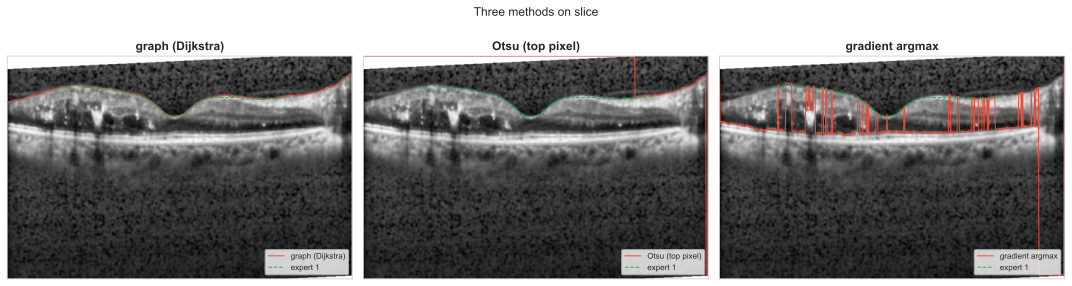

In [132]:
# visual to comparrre

k = 5

img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
pre = preprocess_oct(img_k)
preds = {name: fn(pre) for name, fn in methods.items()}


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, b) in zip(axes, preds.items()):
    ax.imshow(pre, cmap="gray")
    ax.plot(np.arange(W), b, color="#e74c3c", lw=1.0, label=name)
    ax.plot(np.arange(W), expert1[k], color="#27ae60", lw=1.0, ls="--", label="expert 1")
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("Three methods on slice",
             y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### **5.5 Generalization**

To verify generalization of this worflow/pipelin we run the same steps for a second subject (Subject_06) to see if any overfitting occurs or if the method was tailored to the specific slice.


In [133]:
# load "ground truth ILM annotations"
# sub06_ilm.npz done with 'src/extract_slices.py'
gt06 = np.load(GT_DIR / "sub06_ilm.npz")
e1_06 = gt06["expert1"]; e2_06 = gt06["expert2"]
N06 = e1_06.shape[0]


SUB06_DIR = ROOT / "data" / "slices_sub06"

# pipeline
errs06, inters06 = [], []
for k in range(N06):
    img_k = cv.imread(str(SUB06_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
    pre = preprocess_oct(img_k)
    bnd, _ = segment_ilm(pre)
    errs06.append(mean_absolute_surface_distance(bnd, e1_06[k]))
    inters06.append(mean_absolute_surface_distance(e1_06[k], e2_06[k]))

# performance "training"
print(f"Subject_02 (training): "
      f"MASD = {summary_auto[0]:.2f} +/- {summary_auto[1]:.2f} px  "
      f"({summary_auto[0]*PX_TO_UM:.1f} µm); Exp1 vs Exp2 "
      f"{summary_inter[0]:.2f} +/- {summary_inter[1]:.2f} px")

#performance new subjext "generalization"
print(f"Subject_06 (generalization):        "
      f"MASD = {np.nanmean(errs06):.2f} +/- {np.nanstd(errs06):.2f} px  "
      f"({np.nanmean(errs06)*PX_TO_UM:.1f} µm); Exp1 vs Exp2 "
      f"{np.nanmean(inters06):.2f} +/- {np.nanstd(inters06):.2f} px")

Subject_02 (training): MASD = 1.47 +/- 0.43 px  (5.7 µm); Exp1 vs Exp2 1.38 +/- 0.42 px
Subject_06 (generalization):        MASD = 1.28 +/- 0.24 px  (4.9 µm); Exp1 vs Exp2 1.19 +/- 0.23 px


### **5.6 Accuracy of Multiple Layers**

For the layer extension, we evaluate each boundary against its expert annotation. The IS/OS prediction is compared against dataset layer 5 and the RPE/Bruch's prediction against dataset layer 7.

In [134]:
LAYER_MAP = {"ILM": 0, "IS_OS": 5, "RPE": 7}
ml1_all = scipy.io.loadmat("data/raw/2015_BOE_Chiu/Subject_02.mat")["manualLayers1"]
ml2_all = scipy.io.loadmat("data/raw/2015_BOE_Chiu/Subject_02.mat")["manualLayers2"]

rows = []

for k, s in enumerate(slice_indices):
    img_k = cv.imread(str(SLICE_DIR / f"slice_{k:02d}.png"), cv.IMREAD_GRAYSCALE)
    pre = preprocess_oct(img_k)
    layers = segment_three_layers(pre)
    for name, idx in LAYER_MAP.items():
        e1 = ml1_all[idx, :, s]; e2 = ml2_all[idx, :, s]

        rows.append({
            "slice": k,
            "layer": name,
            "MASD [px]": mean_absolute_surface_distance(layers[name], e1),
            "MASD [µm]": mean_absolute_surface_distance(layers[name], e1) * PX_TO_UM,
            "Exp1 v Exp2 [px]": mean_absolute_surface_distance(e1, e2),
        })


df_ml = pd.DataFrame(rows)

summary_ml = df_ml.groupby("layer").agg(
    pred_mean=("MASD [px]", "mean"),
    pred_std =("MASD [px]", "std"),
    pred_um  =("MASD [µm]", "mean"),
    E1vE2_mean=("Exp1 v Exp2 [px]", "mean"),
    E1vE2_std =("Exp1 v Exp2 [px]", "std"),
).round(2)

display(summary_ml.loc[["ILM", "IS_OS", "RPE"]])

,pred_mean,pred_std,pred_um,E1vE2_mean,E1vE2_std
layer,,,,,
ILM,1.47,0.43,5.70,1.38,0.42
IS_OS,1.57,0.49,6.09,1.21,0.30
RPE,1.67,0.25,6.48,1.51,0.55


---

<a id='sec_discussion'></a>

## **6. Discussion**

The Dijkstra approach works extremely well for retinal layer segmentation. With tuned costs and per-column prior the algorithm was able to achieve a MASD of **≈ 1.5 px (≈ 5.8 µm)** on the ILM. This was suprisingly comparable to that between manual segmentations provided with the dataset of ≈ 1.4 px. This remained consistent when tested for generalization on an alternate slice showing a certain robustness for the model without any modifications. When performing sequential Dijkstra on three layers small variations can be seen but remained performant across layers. It is important to note the specific boundaries would likely not be suitable for any data outside of this set as distances may vary for layers following the ILM. The graph structure successfully follows the path with the set constraints, with an important factor being the constraint of one vetical/row shift per horizontal/column shift. The proposed automatic segmentation wildly outperforms naive baselines tested here with mich larger MASDs and visibly worse performance. As these baselines are provided no constraints they fixate on far away pixels unrelated to the desired layer, such as the uncropped band. 

This pipeline provided a clear advantage over manual segmentation compared to in this case Fiji. Manual segmentation takes a minimum of a few minutes per slice and is additionally limited by the available tools and individual's ability to judge where the boundaries lie precisely. Different indiviuals, even experts with the necessary knowledge and skill will differ on the same image or slice which was demonstrated earlier. This autmoatic process is extremely quick and produces results in line with humans and there differences in judgement. The main concern in this case would be generalizing further to other datasets falling outside the specific parameters structured within this project.


### 6.1 Limitations and Future Work

The proposed pipeline constructed here applies solely to the specific dataset, all subjects within the dataset have diabetic macular edema which provides an intact image of the segmented boundaries. Should the targets be distorted or further varied from this dataset the performance would likely be much worse. This is undoubtedly true for hard coded gaps between layers which will vary between scanners, this could be adressed through a configuration file with adjustable parameters necessary to further generalize the pipeline. 
This project looks at the segmentation of boundaries and not thickness which is more clinically significant. Biomarkers often rely on the thickness betweenn boundaries for determination, the natural next step would then be to translate boundaries into thickness maps across the entire volume. 
While this classical computer vision approach is highly transparent, current retinal segmentation relies heavily on deep learning, specifically Convolutional Neural Networks (U-Net architecture). A future study could use the masks generated by this graph-theory algorithm as "weak labels" to train a neural network, combining deep learning with graph theory.


---

<a id='sec_references'></a>

## **References**

* **Chiu, S. J., Allingham, M. J., Mettu, P. S., Cousins, S. W., Izatt, J. A.,
  & Farsiu, S.** (2015). Kernel regression based segmentation of optical
  coherence tomography images with diabetic macular edema.
  *Biomedical Optics Express*, **6**(4), 1172–1194.
  doi:[10.1364/BOE.6.001172](https://doi.org/10.1364/BOE.6.001172)
* **Devalla, S. K., Renukanand, P. K., *et al.*** (2018). DRUNET: a
  dilated-residual U-Net deep learning network to segment optic nerve
  head tissues in optical coherence tomography images. *Biomedical
  Optics Express*, **9**(7), 3244–3265.
* **Dijkstra, E. W.** (1959). A note on two problems in connexion with
  graphs. *Numerische Mathematik*, **1**(1), 269–271.
* **Huang, D., Swanson, E. A., *et al.*** (1991). Optical coherence
  tomography. *Science*, **254**(5035), 1178–1181.
* **Otsu, N.** (1979). A threshold selection method from gray-level
  histograms. *IEEE Trans. Systems, Man, and Cybernetics*, **9**(1),
  62–66.
* **Reinke, A., Tizabi, M. D., *et al.*** (2024). Understanding metric-related
  pitfalls in image analysis validation. *Nature Methods*, **21**, 182–194.
* **Schindelin, J., Arganda-Carreras, I., Frise, E., *et al.*** (2012).
  Fiji: an open-source platform for biological-image analysis.
  *Nature Methods*, **9**, 676–682.
* **Schmitt, J. M., Xiang, S. H., & Yung, K. M.** (1999). Speckle in
  optical coherence tomography. *Journal of Biomedical Optics*, **4**(1),
  95–105.
* **Sobel, I. & Feldman, G.** (1968). A 3×3 isotropic gradient operator
  for image processing. Stanford Artificial Intelligence Project.
* **Tomasi, C. & Manduchi, R.** (1998). Bilateral filtering for gray and
  color images. *Proc. ICCV*, 839–846.
* **Zuiderveld, K.** (1994). Contrast limited adaptive histogram
  equalization. *Graphics Gems IV*, 474–485.

**Software.** OpenCV [Bradski, 2000]; scikit-image [van der Walt et al.,
2014]; NumPy [Harris et al., 2020]; SciPy [Virtanen et al., 2020];
matplotlib [Hunter, 2007]; pandas [McKinney, 2010].

**Dataset.** <http://www.duke.edu/~sf59/Datasets/2015_BOE_Chiu2.zip>.
License: research/educational use; citation of Chiu et al. (2015)

### **Generative AI**

Generative AI was utilized over the course of this project, with Gemini (Google), GitHub Copilot (Microsoft) and Claude (Antrhopic).

These were utlized to better understand concepts as well as a sounding board for ideas and project structure. Aid with coding through use of Copilot in VScode was utilized along with code correction/bugfixes. Organizing modules and project stucture was aided through Claude Code along with plotting visualizations and algortihm implementation. All propsed code was reviewed before implementation.

